# TCR Repertoire Aging Analysis

Reproduces key overlap and aging trends using the Hugging Face AIRR benchmark:

- Data source: isalgo/airr_benchmark (vdjtools/**, refreshed on run)
- Includes full aging metadata with cord-blood donors (age = 0)
- Pairwise overlap in exact, Hamming:1, and Hamming:1 modes
- Diversity analysis from observed repertoires and 250k-read subsamples
- Similarity-first analysis with distance metrics only where required
- UMAP and MDS from pairwise distance metrics

Reference context: Britanova et al. 2016 (age-associated repertoire divergence).

In [1]:
# Environment versions
import platform, importlib
print('Python:', platform.python_version())
for pkg in ('numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn', 'umap', 'mir'):
    try:
        m = importlib.import_module(pkg if pkg != 'umap' else 'umap')
        ver = getattr(m, '__version__', '?')
        print(f'  {pkg}: {ver}')
    except ImportError:
        print(f'  {pkg}: NOT INSTALLED')

Python: 3.12.12
  numpy: 2.4.4
  pandas: 2.3.3
  scipy: 1.17.1
  matplotlib: 3.10.9
  seaborn: 0.13.2


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  umap: 0.5.12
  mir: ?


In [14]:
import importlib
import mir.comparative.overlap as overlap_module
overlap_module = importlib.reload(overlap_module)

from mir.common.repertoire import LocusRepertoire
from mir.common.sampling import downsample
from mir.comparative import clear_pairwise_target_cache
from mir.comparative.overlap import many_vs_pool_overlap, pairwise_overlap, pairwise_overlap_matrix
from mir.utils.memory_debug import process_memory_snapshot
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'STIXGeneral',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
})
sns.set_theme(style='ticks', context='paper')
PALETTE = {
    'exact': '#1B4332',
    'hamming:1': '#B56576',
}
rng = np.random.default_rng(42)

# Drop any previously retained overlap targets when re-running from a warm kernel.
clear_pairwise_target_cache()

EXECUTION_TIMES: dict[str, float] = {}
STRESS_SNAPSHOTS: list[dict[str, float | str]] = []

def _record_stress(tag: str) -> None:
    # Lightweight process/system snapshot for notebook diagnostics.
    snap = process_memory_snapshot(tag)
    try:
        load1, load5, load15 = os.getloadavg()
    except OSError:
        load1, load5, load15 = np.nan, np.nan, np.nan
    STRESS_SNAPSHOTS.append({
        'tag': tag,
        'rss_gb': float(snap['rss_gb']),
        'avail_gb': float(snap['available_gb']),
        'cpu_percent_proc': np.nan,
        'load1': float(load1),
        'load5': float(load5),
        'load15': float(load15),
    })

In [3]:
# Resolve repo root and refresh AIRR benchmark assets from Hugging Face
repo_root = find_repo_root(Path.cwd())

t0 = time.perf_counter()
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=['vdjtools/**'])
asset_refresh_s = time.perf_counter() - t0

VDJTOOLS_DIR = benchmark_root / 'vdjtools'
META_PATH = VDJTOOLS_DIR / 'metadata_aging.txt'

if not META_PATH.exists():
    raise FileNotFoundError(f'Missing expected metadata file: {META_PATH}')

repertoire_lookup = {p.name: p for p in sorted(VDJTOOLS_DIR.glob('*.txt.gz'))}

EXECUTION_TIMES = {'asset_refresh_s': asset_refresh_s}

print(f'Benchmark root      : {benchmark_root}')
print(f'VDJtools directory  : {VDJTOOLS_DIR}')
print(f'Metadata file       : {META_PATH}')
print(f'Refresh time        : {asset_refresh_s:.2f}s')
print(f'Indexed repertoires : {len(repertoire_lookup):,}')

Fetching 322 files: 100%|██████████| 322/322 [00:00<00:00, 1986.94it/s]

Benchmark root      : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark
VDJtools directory  : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjtools
Metadata file       : /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjtools/metadata_aging.txt
Refresh time        : 0.63s
Indexed repertoires : 316


## 1 · Load metadata and repertoires

In [4]:
# Load metadata (polars-first; pandas only for pretty display)
meta = pl.read_csv(META_PATH, separator='\t')

# Normalize column names from benchmark files (e.g., '#file_name').
rename_map = {}
for c in meta.columns:
    c_norm = c.lstrip('#')
    if c_norm != c:
        rename_map[c] = c_norm
if rename_map:
    meta = meta.rename(rename_map)

required_cols = {'sample_id', 'file_name', 'age'}
missing = required_cols - set(meta.columns)
if missing:
    raise ValueError(f'Metadata missing required columns: {sorted(missing)}; found {meta.columns}')

meta = meta.with_columns([
    pl.col('sample_id').cast(pl.Utf8),
    pl.col('file_name').cast(pl.Utf8),
    pl.col('age').cast(pl.Int64),
])

n_rows = meta.height
n_donors = meta.select(pl.col('sample_id').n_unique()).item()
age_min = meta.select(pl.col('age').min()).item()
age_max = meta.select(pl.col('age').max()).item()
n_cord = meta.filter(pl.col('age') == 0).height

print(f'Metadata rows          : {n_rows}')
print(f'Unique donors          : {n_donors}')
print(f'Age range (years)      : {age_min}–{age_max}')
print(f'Cord-blood samples age0: {n_cord}')

meta.head(10).to_pandas()

Metadata rows          : 79
Unique donors          : 79
Age range (years)      : 0–103
Cord-blood samples age0: 8


,file_name,sample_id,sex,age,label
0,A3-i101.txt,A3-i101,F,36,p1-F36
1,A3-i102.txt,A3-i102,F,43,p2-F43
2,A3-i106.txt,A3-i106,F,43,p3-F43
3,A3-i107.txt,A3-i107,F,39,p4-F39
4,A3-i110.txt,A3-i110,F,34,p5-F34
5,A3-i145.txt,A3-i145,F,86,p6-F86
6,A3-i150.txt,A3-i150,F,87,p7-F87
7,A3-i151.txt,A3-i151,F,87,p7-F87
8,A2-i129.txt,A2-i129,M,11,p9-M11
9,A2-i131.txt,A2-i131,M,9,p10-M9


In [5]:
# Load repertoires from metadata rows (TRB per VDJtools file)
parser = VDJtoolsParser(sep='\t')

reps: list[LocusRepertoire] = []
loaded_rows: list[dict[str, object]] = []
missing_rows: list[dict[str, object]] = []

def _resolve_repertoire_path(file_name: str) -> Path | None:
    candidates = [
        file_name,
        f'{file_name}.gz',
        file_name.replace('.txt', '.txt.gz'),
        file_name.replace('.gz', ''),
    ]
    for cand in candidates:
        p = repertoire_lookup.get(cand)
        if p is not None and p.exists():
            return p
    return None

t0 = time.perf_counter()
for row in meta.iter_rows(named=True):
    fn = str(row['file_name'])
    p = _resolve_repertoire_path(fn)
    if p is None:
        missing_rows.append({'file_name': fn, 'sample_id': row['sample_id'], 'age': row['age']})
        continue

    clones = parser.parse(str(p))
    reps.append(LocusRepertoire(clonotypes=clones, locus='TRB'))
    loaded_rows.append({
        'file_name': fn,
        'sample_id': row['sample_id'],
        'sex': row.get('sex', None),
        'age': int(row['age']),
        'source_path': str(p),
    })

# Downsample each repertoire to 100k duplicate_count for memory-safe overlap computation.
DOWNSAMPLE_TARGET = 100_000
reps = [
    downsample(r, DOWNSAMPLE_TARGET, random_seed=42) if r.clonotype_count > 0 else r
    for r in reps
]

load_repertoires_s = time.perf_counter() - t0
EXECUTION_TIMES['load_repertoires_s'] = load_repertoires_s

meta_valid = pl.DataFrame(loaded_rows)
if meta_valid.height == 0:
    raise RuntimeError('No repertoires were loaded. Check file name normalization against VDJtools paths.')

sample_ids = meta_valid['sample_id'].to_list()
ages = meta_valid['age'].to_list()
sizes = np.array([r.clonotype_count for r in reps], dtype=int)

# Cohort-level diversity: unique clonotypes across all donors in aavj space.
cohort_unique_aavj = len({(c.junction_aa, c.v_gene, c.j_gene) for rep in reps for c in rep.clonotypes if c.junction_aa})

print(f'Loaded repertoires : {len(reps)} in {load_repertoires_s:.2f}s')
print(f'Loaded donors      : {meta_valid.select(pl.col("sample_id").n_unique()).item()}')
print(f'Loaded age range   : {min(ages)}–{max(ages)} years')
print(f'Clonotype count    : min={sizes.min():,} median={int(np.median(sizes)):,} max={sizes.max():,}')
print(f'Cohort unique aavj : {cohort_unique_aavj:,}')

if missing_rows:
    miss_df = pl.DataFrame(missing_rows)
    print(f'Missing files for metadata rows: {miss_df.height}')
    display(miss_df.head(10).to_pandas())
else:
    print('All metadata rows resolved to repertoire files.')

_record_stress('after_load_repertoires')

/Users/mikesh/vcs/mirpy/mir/common/sampling.py:69: UserWarning: downsample_count (100000) >= total duplicate count (50047); no downsampling performed
  warnings.warn(
/Users/mikesh/vcs/mirpy/mir/common/sampling.py:69: UserWarning: downsample_count (100000) >= total duplicate count (35571); no downsampling performed
  warnings.warn(
/Users/mikesh/vcs/mirpy/mir/common/sampling.py:69: UserWarning: downsample_count (100000) >= total duplicate count (78463); no downsampling performed
  warnings.warn(


Loaded repertoires : 79 in 94.06s
Loaded donors      : 79
Loaded age range   : 0–103 years
Clonotype count    : min=12,439 median=51,303 max=93,154
Cohort unique aavj : 3,683,755
All metadata rows resolved to repertoire files.


## 2 · Diversity and 300k-read subsampling

In [6]:
# Compute observed diversity and diversity after 50k-read subsampling (adjusted for 100k rep downsample)
DOWNSAMPLE_READS = 50_000

diversity_rows: list[dict[str, object]] = []
for i, (sid, age, rep) in enumerate(zip(sample_ids, ages, reps)):
    total_reads = int(sum(cl.duplicate_count for cl in rep.clonotypes))
    observed_diversity = int(rep.clonotype_count)

    if total_reads >= DOWNSAMPLE_READS:
        rep_ds = downsample(rep, DOWNSAMPLE_READS, random_seed=42 + i)
        diversity_50k = int(rep_ds.clonotype_count)
    else:
        diversity_50k = None

    diversity_rows.append({
        'sample_id': sid,
        'age': int(age),
        'total_reads': total_reads,
        'observed_diversity': observed_diversity,
        'diversity_50k': diversity_50k,
    })

diversity_df = pl.DataFrame(diversity_rows)
print(f'Samples with >= {DOWNSAMPLE_READS:,} reads: {diversity_df.filter(pl.col("diversity_50k").is_not_null()).height}/{diversity_df.height}')

diversity_df.sort('age').head(12).to_pandas()

Samples with >= 50,000 reads: 78/79


,sample_id,age,total_reads,observed_diversity,diversity_50k
0,A5-S14,0,100000,82370,36065
1,A5-S15,0,100000,66539,32831
2,A5-S16,0,100000,88303,37232
3,A5-S17,0,100000,92095,37961
4,A5-S18,0,100000,93154,38139
5,A5-S11,0,100000,89060,37480
6,A5-S12,0,100000,90139,37524
7,A5-S13,0,100000,91912,37973
8,A2-i132,6,100000,85227,35730
9,A2-i131,9,100000,71013,31271


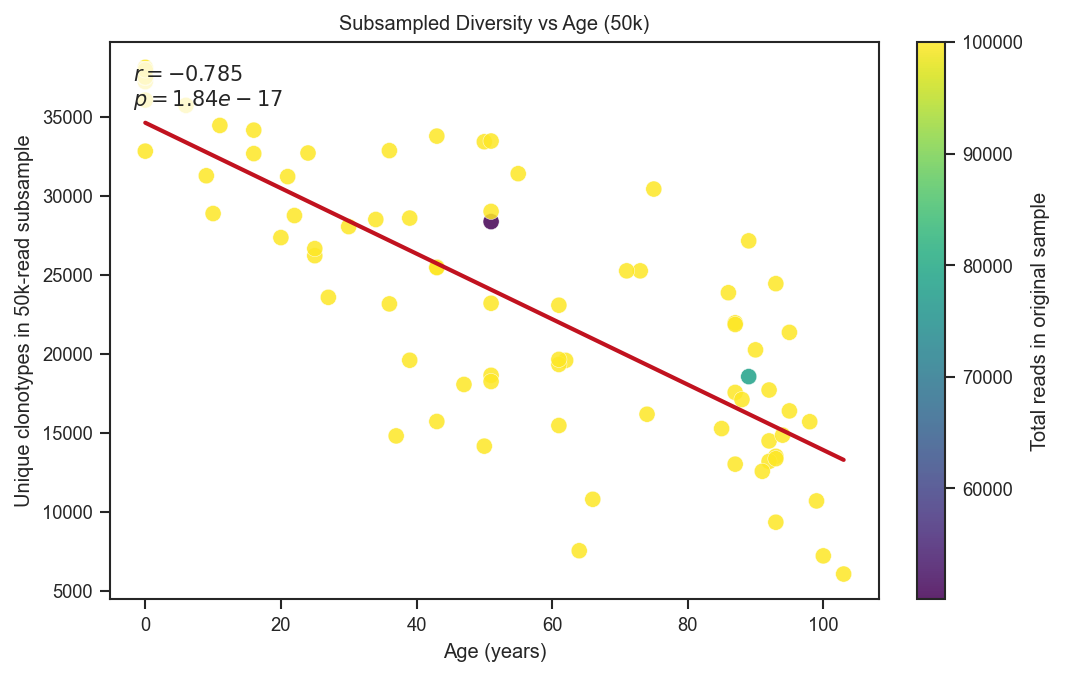

In [7]:
# Diversity at 50k reads versus age
plot_df = diversity_df.filter(pl.col('diversity_50k').is_not_null())

fig, ax = plt.subplots(figsize=(7.0, 4.4), constrained_layout=True)
sc = ax.scatter(
    plot_df['age'].to_numpy(),
    plot_df['diversity_50k'].to_numpy(),
    c=plot_df['total_reads'].to_numpy(),
    cmap='viridis',
    s=60,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.25,
)

x = plot_df['age'].to_numpy().astype(float)
y = plot_df['diversity_50k'].to_numpy().astype(float)
mask = np.isfinite(x) & np.isfinite(y)
slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
xr = np.linspace(x[mask].min(), x[mask].max(), 200)
ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2.0)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Unique clonotypes in 50k-read subsample')
ax.set_title('Subsampled Diversity vs Age (50k)')
ax.text(
    0.03,
    0.96,
    f'$r={r:.3f}$\n$p={p:.2e}$',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2.5),
)
plt.colorbar(sc, ax=ax, label='Total reads in original sample')
plt.show()

## 3 · Pairwise overlap matrices and metric conversion

In [8]:
# Compute pairwise overlap matrices directly (no pilot estimation), with immediate progress logs.
N_JOBS_MATRIX = 4  # safe: 100k-downsampled reps keep qi_list small enough for 4 spawn workers
OVERLAP_SPACE = 'aavj'
TARGET_CELL_SECONDS = 15 * 60

results: dict[str, pl.DataFrame] = {}
pairwise_timing_rows: list[dict[str, object]] = []

for mode_label, metric, threshold in [
    ('exact', 'exact', 0),
    ('hamming:1', 'hamming', 1),
]:
    print(f"[{mode_label}] starting pairwise matrix...")
    t0 = time.perf_counter()
    df_pd = pairwise_overlap_matrix(
        reps,
        sample_ids=sample_ids,
        metric=metric,
        threshold=threshold,
        overlap_space=OVERLAP_SPACE,
        n_jobs=N_JOBS_MATRIX,
    )
    elapsed = time.perf_counter() - t0

    df = pl.from_pandas(df_pd)
    results[mode_label] = df

    try:
        import psutil
        n_jobs_effective = psutil.cpu_count(logical=False) or os.cpu_count() or 1
    except Exception:
        n_jobs_effective = os.cpu_count() or 1

    pairwise_timing_rows.append({
        'mode': mode_label,
        'n_pairs': df.height,
        'seconds': elapsed,
        'n_jobs_requested': N_JOBS_MATRIX,
        'n_jobs_effective': int(n_jobs_effective),
        'within_target': elapsed <= TARGET_CELL_SECONDS,
    })

    status = 'OK' if elapsed <= TARGET_CELL_SECONDS else 'OVER_TARGET'
    print(
        f"[{mode_label}] done pairs={df.height} n_jobs={int(n_jobs_effective)} "
        f"time={elapsed:.2f}s [{status}]"
    )

pairwise_timing = pl.DataFrame(pairwise_timing_rows)
EXECUTION_TIMES['pairwise_total_s'] = float(pairwise_timing.select(pl.col('seconds').sum()).item())

print('\nPairwise timing summary:')
display(pairwise_timing.to_pandas())
_record_stress('after_pairwise_matrix')

[exact] starting pairwise matrix...


/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:468: RuntimeWarning: Excluded 1814 non-coding clonotypes from amino-acid overlap (query:aavj).
  _emit_noncoding_warning(dropped_noncoding, context=f"query:{overlap_space}")
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:468: RuntimeWarning: Excluded 1043 non-coding clonotypes from amino-acid overlap (query:aavj).
  _emit_noncoding_warning(dropped_noncoding, context=f"query:{overlap_space}")
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:468: RuntimeWarning: Excluded 1199 non-coding clonotypes from amino-acid overlap (query:aavj).
  _emit_noncoding_warning(dropped_noncoding, context=f"query:{overlap_space}")
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:468: RuntimeWarning: Excluded 1901 non-coding clonotypes from amino-acid overlap (query:aavj).
  _emit_noncoding_warning(dropped_noncoding, context=f"query:{overlap_space}")
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:468: RuntimeWarning: Excluded 2062 non-coding clo

[exact] done pairs=3081 n_jobs=16 time=27.47s [OK]
[hamming:1] starting pairwise matrix...
[hamming:1] done pairs=3081 n_jobs=16 time=555.66s [OK]

Pairwise timing summary:


,mode,n_pairs,seconds,n_jobs_requested,n_jobs_effective,within_target
0,exact,3081,27.470395,4,16,True
1,hamming:1,3081,555.663512,4,16,True


## 4 · Pool sample and per-sample overlap with pool

In [9]:
# Build pooled repertoire by concatenating clonotypes from all donors.
all_clones = []
for rep in reps:
    all_clones.extend(rep.clonotypes)

pool_rep = LocusRepertoire(clonotypes=all_clones, locus='TRB')
print(f'Pooled repertoire: {pool_rep.clonotype_count:,} clonotypes (sum of all samples)')

Pooled repertoire: 4,145,989 clonotypes (sum of all samples)


In [ ]:
# Compute donor-vs-pool overlap with the shared-worker many-vs-pool API.
POOL_N_JOBS = 4  # limit to 4 to avoid memory exhaustion
POOL_BATCH_SIZE = max(1, len(reps) // (POOL_N_JOBS * 2))
pool_results: dict[str, pl.DataFrame] = {}
pool_timing_rows: list[dict[str, object]] = []

t0_all = time.perf_counter()
for mode_label, metric, threshold in [
    ('exact', 'exact', 0),
    ('hamming:1', 'hamming', 1),
]:
    print(f"[{mode_label}] donor-vs-pool starting...")
    t0 = time.perf_counter()

    df = many_vs_pool_overlap(
        reps,
        pool_rep,
        sample_ids=sample_ids,
        ages=ages,
        metric=metric,
        threshold=threshold,
        overlap_space=OVERLAP_SPACE,
        n_jobs=POOL_N_JOBS,
        batch_size=POOL_BATCH_SIZE,
    )

    elapsed = time.perf_counter() - t0
    pool_results[mode_label] = df
    pool_timing_rows.append({'mode': mode_label, 'n_samples': len(df), 'seconds': elapsed})
    print(f"[{mode_label}] donor-vs-pool done in {elapsed:.2f}s")

pool_timing = pl.DataFrame(pool_timing_rows)
EXECUTION_TIMES['pool_total_s'] = time.perf_counter() - t0_all

print('\nPool overlap timing summary:')
display(pool_timing.to_pandas())
_record_stress('after_pool_overlap')

[exact] donor-vs-pool starting...


/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 123537 non-coding clonotypes from amino-acid overlap (query:aavj).
  target_n: int | None = None,
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 1814 non-coding clonotypes from amino-acid overlap (query:aavj).
  target_n: int | None = None,
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 1043 non-coding clonotypes from amino-acid overlap (query:aavj).
  target_n: int | None = None,
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 1199 non-coding clonotypes from amino-acid overlap (query:aavj).
  target_n: int | None = None,
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 1901 non-coding clonotypes from amino-acid overlap (query:aavj).
  target_n: int | None = None,
/Users/mikesh/vcs/mirpy/mir/comparative/overlap.py:585: RuntimeWarning: Excluded 2062 non-coding clonotypes from 

AttributeError: 'DataFrame' object has no attribute 'height'

## 5 · F and D metrics vs absolute age difference

In [ ]:
def _attach_pair_ages(df_pairs: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    """Attach age columns and absolute age difference to pairwise rows."""
    age_map = meta_df.select(['sample_id', 'age']).rename({'sample_id': 'sid'})

    out = (
        df_pairs
        .join(age_map.rename({'sid': 'sample_id_1', 'age': 'age1'}), on='sample_id_1', how='left')
        .join(age_map.rename({'sid': 'sample_id_2', 'age': 'age2'}), on='sample_id_2', how='left')
        .with_columns((pl.col('age1') - pl.col('age2')).abs().alias('age_diff'))
    )
    return out


def _outlier_threshold_iqr(values: np.ndarray, k: float = 3.0) -> float:
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    return q3 + k * iqr

In [ ]:
# Pairwise similarity versus absolute age difference (exact mode),
# with distance-like metrics computed only for plotting.
df_exact_age = _attach_pair_ages(results['exact'], meta_valid)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.2), sharex='col', constrained_layout=True)
metric_specs = [
    ('f_similarity', 'F similarity', lambda s: 1.0 - s),
    ('d_similarity', 'D similarity', lambda s: np.where(s > 0, 1.0 / s, np.nan)),
]

for col_i, (sim_col, label, to_metric) in enumerate(metric_specs):
    x = df_exact_age['age_diff'].to_numpy().astype(float)
    sim = df_exact_age[sim_col].to_numpy().astype(float)
    y = to_metric(sim)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    top_ax = axes[0, col_i]
    bot_ax = axes[1, col_i]

    out_cut = _outlier_threshold_iqr(y, k=3.0)
    out_mask = y > out_cut

    bot_ax.scatter(x[~out_mask], y[~out_mask], c=x[~out_mask], cmap='viridis', s=22, alpha=0.75, edgecolors='none')
    if out_mask.any():
        top_ax.scatter(x[out_mask], y[out_mask], c=x[out_mask], cmap='viridis', s=30, alpha=0.9, edgecolors='black', linewidths=0.25)
        top_ax.set_ylim(np.nanmin(y[out_mask]) * 0.98, np.nanmax(y[out_mask]) * 1.02)
    else:
        top_ax.scatter(x, y, c=x, cmap='viridis', s=22, alpha=0.75, edgecolors='none')

    bot_ax.set_ylim(np.nanmin(y[~out_mask]) * 0.98, np.nanmax(y[~out_mask]) * 1.02)

    slope, intercept, r, p, _ = stats.linregress(x, y)
    xr = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    bot_ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2.0)

    top_ax.set_title(f'{label} metric')
    top_ax.text(
        0.03,
        0.92,
        f'outliers: {int(out_mask.sum())}',
        transform=top_ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2),
    )
    bot_ax.text(
        0.03,
        0.96,
        f'$r={r:.3f}$\\n$p={p:.2e}$',
        transform=bot_ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2.5),
    )

    top_ax.spines['bottom'].set_visible(False)
    bot_ax.spines['top'].set_visible(False)
    top_ax.tick_params(labelbottom=False)

    top_ax.set_ylabel('Metric')
    bot_ax.set_ylabel('Metric')
    bot_ax.set_xlabel('Absolute age difference (years)')

fig.suptitle('Pairwise Metrics vs Absolute Age Difference (Exact)', y=1.02, fontsize=13)
plt.show()

# Report strongest D-metric outliers for interpretation.
d_metric_exact = np.where(df_exact_age['d_similarity'].to_numpy().astype(float) > 0, 1.0 / df_exact_age['d_similarity'].to_numpy().astype(float), np.nan)
outlier_report = (
    df_exact_age
    .with_columns(pl.Series('d_metric', d_metric_exact))
    .with_columns((pl.col('d_metric') > _outlier_threshold_iqr(d_metric_exact[np.isfinite(d_metric_exact)], 3.0)).alias('d_outlier'))
    .filter(pl.col('d_outlier'))
    .select(['sample_id_1', 'sample_id_2', 'age1', 'age2', 'age_diff', 'd_similarity', 'f_similarity', 'd_metric'])
    .sort('d_metric', descending=True)
)
print(f'N pairs: {df_exact_age.height}')
if outlier_report.height:
    print('Top D-metric outliers (likely near-identical or technical replicates):')
    display(outlier_report.head(10).to_pandas())

In [ ]:
# Donor-vs-pool similarity trends by age.
df_pool_exact = pool_results['exact']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

for ax, (sim_col, label) in zip(axes, [
    ('f_similarity', 'F similarity (vs pool)'),
    ('d_similarity', 'D similarity (vs pool)'),
]):
    x = df_pool_exact['age'].to_numpy().astype(float)
    y = df_pool_exact[sim_col].to_numpy().astype(float)
    mask = np.isfinite(x) & np.isfinite(y)

    sc = ax.scatter(
        x[mask],
        y[mask],
        c=x[mask],
        cmap='viridis',
        s=58,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.25,
        rasterized=True,
    )

    slope, intercept, r, p, _ = stats.linregress(x[mask], y[mask])
    xr = np.linspace(x[mask].min(), x[mask].max(), 200)
    ax.plot(xr, slope * xr + intercept, color='#C1121F', lw=2.0)

    ax.set_xlabel('Age (years)')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.text(
        0.03,
        0.96,
        f'$r={r:.3f}$\\n$p={p:.2e}$',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2.5),
    )
    plt.colorbar(sc, ax=ax, label='Age')

fig.suptitle('Overlap With Cohort Pool Across Aging', y=1.02, fontsize=13)
plt.show()

## 6 · UMAP and MDS from pairwise distance metrics

In [ ]:
def _to_symmetric_matrix(df_pairs: pl.DataFrame, col: str, ids: list[str]) -> np.ndarray:
    """Convert long-format pairwise table to symmetric NxN matrix."""
    n = len(ids)
    id_to_idx = {sid: i for i, sid in enumerate(ids)}
    mat = np.zeros((n, n), dtype=float)

    for row in df_pairs.select(['sample_id_1', 'sample_id_2', col]).iter_rows(named=True):
        i = id_to_idx[row['sample_id_1']]
        j = id_to_idx[row['sample_id_2']]
        v = float(row[col])
        mat[i, j] = v
        mat[j, i] = v
    return mat


def _f_metric_from_similarity(f_similarity: np.ndarray) -> np.ndarray:
    return 1.0 - f_similarity


def _d_metric_from_similarity(d_similarity: np.ndarray) -> np.ndarray:
    with np.errstate(divide='ignore', invalid='ignore'):
        d_metric = np.where(d_similarity > 0, 1.0 / d_similarity, np.nan)
    if np.isfinite(d_metric).any():
        max_finite = np.nanmax(d_metric[np.isfinite(d_metric)])
        d_metric = np.nan_to_num(d_metric, nan=max_finite)
    else:
        d_metric = np.zeros_like(d_similarity)
    return d_metric

In [ ]:
try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed — skipping UMAP. Install with: pip install umap-learn')

In [ ]:
if HAS_UMAP:
    # Build exact-mode distance matrices for embedding.
    f_similarity_exact = _to_symmetric_matrix(results['exact'], 'f_similarity', sample_ids)
    d_similarity_exact = _to_symmetric_matrix(results['exact'], 'd_similarity', sample_ids)

    f_metric_exact = _f_metric_from_similarity(f_similarity_exact)
    d_metric_exact = _d_metric_from_similarity(d_similarity_exact)

    np.fill_diagonal(f_metric_exact, 0.0)
    np.fill_diagonal(d_metric_exact, 0.0)

    umap_f = UMAP(
        n_components=2,
        metric='precomputed',
        n_neighbors=min(10, len(reps) - 1),
        min_dist=0.08,
        random_state=42,
    ).fit_transform(f_metric_exact)

    mds_f = MDS(
        n_components=2,
        dissimilarity='precomputed',
        normalized_stress='auto',
        random_state=42,
        n_init=4,
        max_iter=400,
    ).fit_transform(f_metric_exact)

    umap_d = UMAP(
        n_components=2,
        metric='precomputed',
        n_neighbors=min(10, len(reps) - 1),
        min_dist=0.08,
        random_state=42,
    ).fit_transform(d_metric_exact)

    mds_d = MDS(
        n_components=2,
        dissimilarity='precomputed',
        normalized_stress='auto',
        random_state=42,
        n_init=4,
        max_iter=400,
    ).fit_transform(d_metric_exact)

    EMBEDDINGS = {
        'UMAP (F metric)': umap_f,
        'MDS (F metric)': mds_f,
        'UMAP (D metric)': umap_d,
        'MDS (D metric)': mds_d,
    }
    print('Computed embeddings:', ', '.join(EMBEDDINGS.keys()))

In [ ]:
if HAS_UMAP:
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.2), constrained_layout=True)

    for ax, (title, emb) in zip(axes.ravel(), EMBEDDINGS.items()):
        sc = ax.scatter(
            emb[:, 0],
            emb[:, 1],
            c=np.array(ages, dtype=float),
            cmap='viridis',
            s=64,
            alpha=0.9,
            linewidths=0.25,
            edgecolors='white',
        )
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label='Age (years)')

    fig.suptitle('Aging Structure in Distance Embeddings', y=1.01, fontsize=13)
    plt.show()

## 6 · Compare exact vs Hamming:1

In [ ]:
# Compare F and D metric distributions across overlap modes with fixed binning.

f_metric_by_mode = {
    mode_label: (1.0 - df['f_similarity']).drop_nulls().to_numpy()
    for mode_label, df in results.items()
}
d_metric_by_mode = {
    mode_label: pl.Series(
        np.where(df['d_similarity'].to_numpy() > 0, 1.0 / df['d_similarity'].to_numpy(), np.nan)
    ).drop_nulls().to_numpy()
    for mode_label, df in results.items()
}

def _fixed_edges(series_by_mode: dict[str, np.ndarray], n_bins: int = 36) -> np.ndarray:
    all_vals = np.concatenate([v for v in series_by_mode.values() if len(v) > 0])
    lo = float(np.nanmin(all_vals))
    hi = float(np.nanmax(all_vals))
    if hi <= lo:
        hi = lo + 1e-6
    return np.linspace(lo, hi, n_bins + 1)

f_edges = _fixed_edges(f_metric_by_mode, n_bins=36)
d_edges = _fixed_edges(d_metric_by_mode, n_bins=36)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), constrained_layout=True)

for mode_label in ('exact', 'hamming:1'):
    axes[0].hist(
        f_metric_by_mode[mode_label],
        bins=f_edges,
        alpha=0.45,
        label=mode_label,
        color=PALETTE[mode_label],
        density=True,
        edgecolor='white',
        linewidth=0.35,
    )
    axes[1].hist(
        d_metric_by_mode[mode_label],
        bins=d_edges,
        alpha=0.45,
        label=mode_label,
        color=PALETTE[mode_label],
        density=True,
        edgecolor='white',
        linewidth=0.35,
    )

axes[0].set_xlabel('F metric (1 − F similarity)')
axes[0].set_ylabel('Density')
axes[0].set_title('F Metric Distribution')

axes[1].set_xlabel('D metric (1 / D similarity)')
axes[1].set_ylabel('Density')
axes[1].set_title('D Metric Distribution')

axes[0].legend(frameon=False, ncol=1, loc='upper right')
axes[1].legend(frameon=False, ncol=1, loc='upper right')

plt.show()

In [ ]:
# Similarity summary table (reported, not plotted): F, D, F2, Jaccard,
# Szymkiewicz-Simpson, Morisita-Horn.
summary_rows = []
for mode_label, df in results.items():
    for metric_col in (
        'f_similarity',
        'd_similarity',
        'f2_similarity',
        'jaccard',
        'szymkiewicz_simpson',
        'morisita_horn',
    ):
        vals = df.select(pl.col(metric_col)).drop_nulls().to_series()
        if vals.len() == 0:
            continue
        summary_rows.append({
            'mode': mode_label,
            'metric': metric_col,
            'mean': float(vals.mean()),
            'median': float(vals.median()),
            'std': float(vals.std()),
            'max': float(vals.max()),
        })

summary_df = pl.DataFrame(summary_rows).sort(['mode', 'metric'])
display(summary_df.to_pandas())

## 7 · Age correlation summary

In [ ]:
# Spearman correlation of similarity vs age for donor-vs-pool results.
print('\nPool-overlap: Spearman correlation with age')
print(f'{"Mode":<18} {"Similarity":<15} {"rho":>8} {"p-value":>12}')
print('-' * 60)

for mode_label, df in pool_results.items():
    for sim_col in ('f_similarity', 'd_similarity'):
        vals = df[sim_col].to_numpy().astype(float)
        age_vals = df['age'].to_numpy().astype(float)
        mask = np.isfinite(vals) & np.isfinite(age_vals)
        rho, p = stats.spearmanr(age_vals[mask], vals[mask])
        print(f'{mode_label:<18} {sim_col:<15} {rho:>8.3f} {p:>12.3e}')

_record_stress('final')

print('\nExecution timing (seconds):')
display(pd.DataFrame([EXECUTION_TIMES]).T.rename(columns={0: 'seconds'}))

stress_df = pd.DataFrame(STRESS_SNAPSHOTS)
if not stress_df.empty:
    print('\nStress diagnostics:')
    display(stress_df)
    print('Peak RSS (GB):', f"{stress_df['rss_gb'].max():.2f}")
    print('Min available RAM (GB):', f"{stress_df['avail_gb'].min():.2f}")
    print('Max process CPU% sample:', f"{stress_df['cpu_percent_proc'].max():.1f}")